#**Understanding Booking Cancellation Behavior to Identify Drop-off Patterns in an Online Travel Platform**

#Import Libraries

In [1]:
# Core libraries for data manipulation
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Improve visualization appearance
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

This section initializes the core tools :
1. Pandas for data manipulation
2. numpy for numericel operations
3. matpolib and seaborn for visualization

#Load Data

In [2]:
df = pd.read_csv('hotel_bookings.csv')

In [3]:
#Display first rows
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


This dataset contains hotel booking transaction data

This step ensures the data is loaded correctly and allows us to preview its stucture

#Data Understanding

In [4]:
df.shape

(119390, 32)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


The dataset contains 119,390 rows and 32 columns with both numerical and categorical types. Most data is complete, but some columns like children, country, agent, and company have missing values. The cancellation rate is about 37%, and the average lead_time is 104 days with high variability. The data covers the period from 2015 to 2017

#Data Cleaning

In [7]:
#Check missing values
missing = df.isnull().sum()
missing[missing>0]

,0
children,4
country,488
agent,16340
company,112593


The first step aims to identify which columns contain empty data. By using the isnull().sum() function, you can see the number of missing rows for each variable. In this case, significant missing values were found in the children, country, agent, and company columns, which require immediate attention.

In [9]:
# Handle missing values
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

Once the problematic columns were identified, you performed imputation or data filling. You chose to fill categorical columns with the word 'Unknown' and numerical columns with 0. This step is crucial so that the data rows can still be processed by analysis models or machines without causing errors due to null values.

In [10]:
#Cross Check missing values
missing = df.isnull().sum()
missing[missing>0]

,0


In [11]:
#Check Duplicates
df.duplicated().sum()

np.int64(31994)

In [12]:
# Remove duplicates
df.drop_duplicates(inplace=True)

After handling the missing values, you checked for redundant data using df.duplicated().sum(). Since 31,994 duplicate entries were found, you removed them using the drop_duplicates() function. This is done to ensure each data row is unique, preventing bias or double-counting during the subsequent analysis.

In [13]:
#Cross Check Duplicates
df.duplicated().sum()

np.int64(0)

The final step is to re-verify the entire cleaning process. The final results show a value of 0 for both missing values and duplicates. This indicates that your dataset is now clean, consistent, and ready to be used for further visualization or modeling stages.

#Cancelation Rate

In [14]:
cancel_rate = df['is_canceled'].mean()
print(f"Cancellation Rate: {cancel_rate:.2%}")

Cancellation Rate: 27.49%


A cancellation rate of 27.49% indicates that roughly one in four bookings does not result in a successful transaction. This is relatively high, suggesting that a significant portion of users fail to complete the booking process.

#Visualization - Booking Outcome

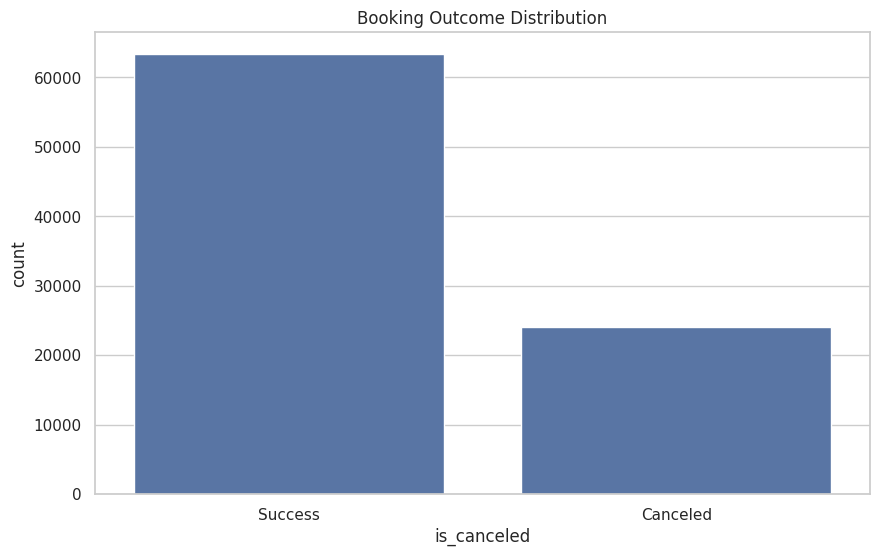

In [21]:
sns.countplot(x='is_canceled', data=df)
plt.title('Booking Outcome Distribution')
plt.xticks([0,1], ['Success', 'Canceled'])
plt.savefig('booking_outcome.png')
plt.show()

The chart shows that successful bookings significantly outnumber canceled ones. However, the number of cancellations remains substantial in absolute terms.

#Analyisis - Lead Time

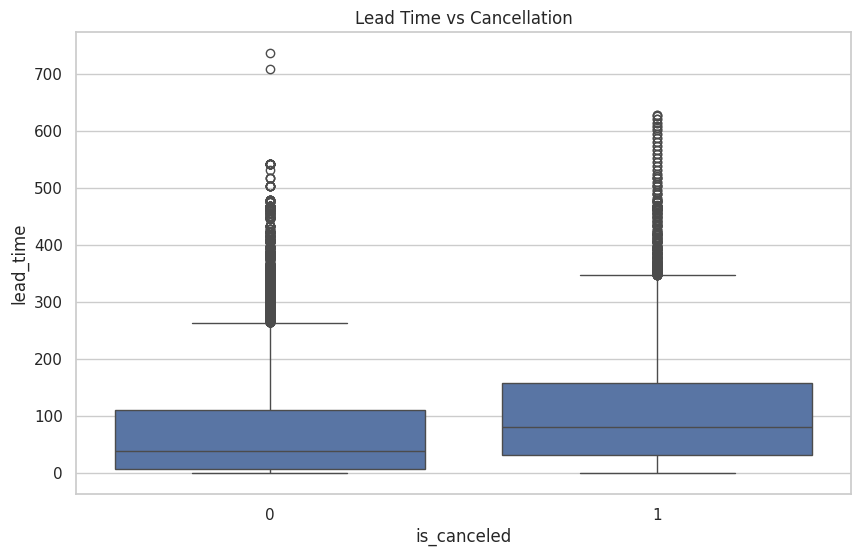

In [22]:
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.title('Lead Time vs Cancellation')
plt.savefig('lead_time.png')
plt.show()

The boxplot shows that canceled bookings (1) generally have higher lead times compared to non-canceled bookings (0). The median and spread are also larger, indicating that bookings made further in advance tend to vary more and are generally higher.

#Analysis - Customer Type

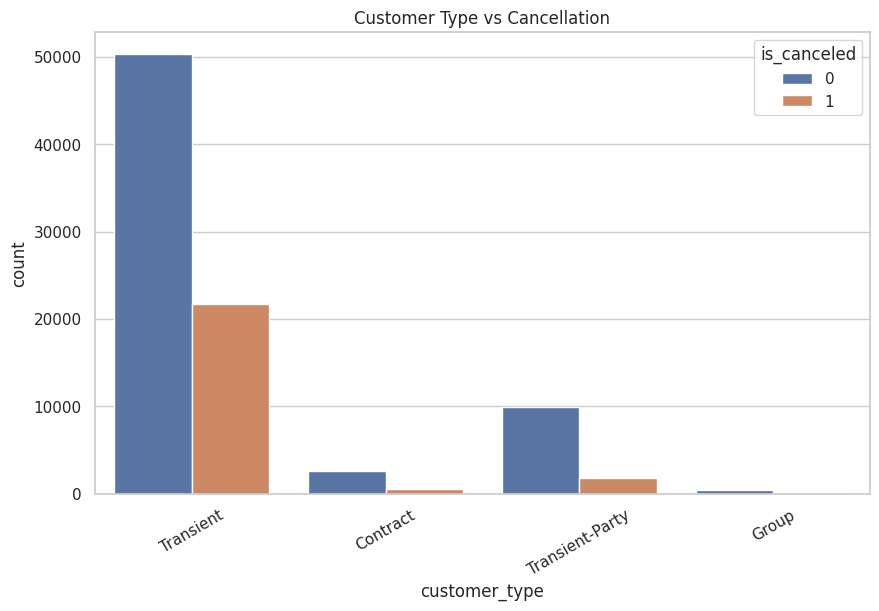

In [23]:
sns.countplot(x='customer_type', hue='is_canceled', data=df)
plt.xticks(rotation=30)
plt.title('Customer Type vs Cancellation')
plt.savefig('customer_type.png')
plt.show()

The chart shows that Transient customers dominate both total bookings and cancellations. In contrast, Contract and Group customers exhibit significantly lower cancellation counts.

#EDA

From the exploratory data analysis, booking behavior on the online travel platform shows instability toward the final stage of the transaction.

The cancellation rate stands at 27.49%, indicating that while most users complete their bookings, a significant portion drops off before finalizing the transaction.

Further analysis reveals that key factors associated with cancellations include lead time and customer type.

Lead time distribution shows that bookings made far in advance are more likely to be canceled. This suggests that the longer the time gap between booking and check-in, the higher the uncertainty and likelihood of plan changes.

Additionally, customer segmentation indicates that Transient customers dominate both total bookings and cancellations. This suggests that individual users without contractual commitment are more flexible and more likely to cancel compared to contract or group customers.

#INSIGHT

Drop-off in the booking process is not random, but driven by a combination of user flexibility and time uncertainty.

Users who:
1. book far in advance
2. have low commitment (Transient)

are significantly more likely to abandon the transaction.

This indicates that the core issue lies not only in user volume, but in the quality of user intent entering the booking funnel.

#RECOMMENDATION

1. Target high-risk users (long lead time & transient) with reminders or incentives to reduce cancellations
2. Send reminders closer to check-in dates to reduce uncertainty and forgotten bookings
3. Introduce partial payment or stricter cancellation policies to increase commitment
4. Improve checkout/payment experience, as this is the most critical drop-off stage
5. Apply segment-specific strategies, as customer behavior varies significantly